In [ ]:
import warnings
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from utils.model_fitting import *
from utils.plots import *
from rl.models import Tonic_DA_model
from utils.path import PathConfig,FigureWithData

warnings.filterwarnings("ignore")
rseed =1234
np.random.seed(rseed)
random.seed(rseed)

fig_dir = os.path.join('figures', 'figure_S9')
data_fig_dir = os.path.join('data', 'source_data', 'figure_S9')
os.makedirs(fig_dir, exist_ok=True)
os.makedirs(data_fig_dir, exist_ok=True)


## Tonic Dopamine model

This notebook performs the basic predictions of the tonic Dopamine model proposed in the manuscript:  *Romero Pinto, S., & Uchida, N. (2023). **Tonic dopamine and biases in value learning linked through a biologically inspired reinforcement learning model***

**Note:** No data is needed for this notebook


In [2]:
md = Tonic_DA_model()
DA = md.DA
ec50_1 = md.ec50_1
ec50_2 = md.ec50_2
delta_DA = md.delta_DA
slope_D1_log, slope_D2_log = md.compute_sensitivities(type_scale='log')
taus_log = md.compute_taus(type_scale='log')
slope_D1_lin, slope_D2_lin = md.compute_sensitivities(type_scale='lin')
taus_lin = md.compute_taus(type_scale='lin')
occ_D1, occ_D2, DA_occ =md.compute_dose_occupancy(DA_range = [-2,6])
colorD1 = 'deepskyblue'
colorD2 = 'hotpink'

### Extended data figure 9

The qualitative aspects of Model 1 are preserved irrespective of the assumption made about the changes in baseline dopamine caused by dopamine transients.  

Below are the computation of receptor sensitivities assuming logarithmic (left) or linear (middle) changes in baseline dopamine induced by dopamine transients (logΔDA,linΔDA, respectively). 
- The absolute magnitude of the slopes differs depending on the assumption made about the changes in baseline dopamine (logarithmic vs linear) but the asymmetric scaling factor presents only a small shift in the curve as a function of baseline dopamine (right). 
- The qualitative aspects of the model (i.e., non-monotonic relationship of the asymmetric scaling factor with baseline dopamine) is preserved regardless on this assumption.


Saved figure to figures/figure_S9/figure_S9.pdf
Saved data and stats to data/figure_data/figure_S9/figure_S9.txt


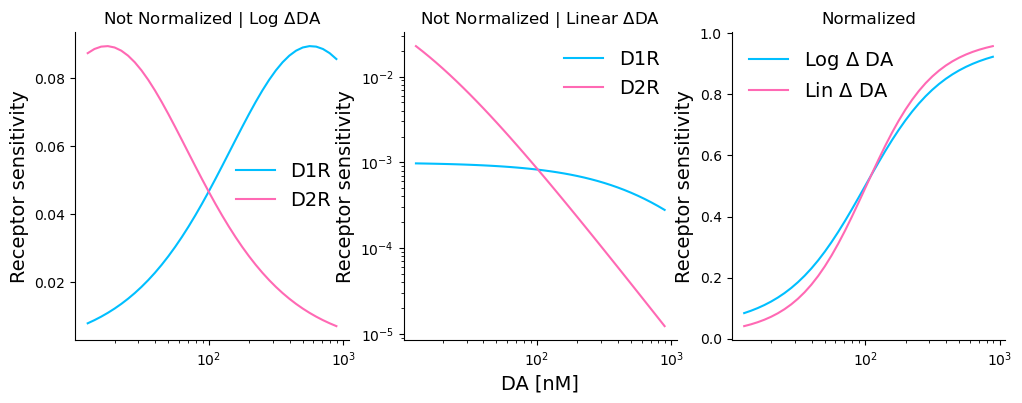

In [5]:

fig, ax = plt.subplots(1,3,figsize = (12,4))
fig_data = FigureWithData(fig)


ax[0].semilogx(DA,slope_D1_log,color=colorD1,linewidth=1.5, label= 'D1R')
ax[0].semilogx(DA,slope_D2_log,color=colorD2,linewidth=1.5, label = 'D2R')
plot_config(ax[0],'','Receptor sensitivity',14,True)
title_(ax[0],r'Not Normalized | Log $\Delta$DA')


ax[1].loglog(DA,slope_D1_lin,color=colorD1,linewidth=1.5, label= 'D1R')
ax[1].loglog(DA,slope_D2_lin,color=colorD2,linewidth=1.5, label = 'D2R')
plot_config(ax[1],'DA [nM]','Receptor sensitivity',14,True)
title_(ax[1],r'Not Normalized | Linear $\Delta$DA')

ax[2].semilogx(DA,taus_log,color=colorD1,linewidth=1.5, label= r'Log $\Delta$ DA')
ax[2].semilogx(DA,taus_lin,color=colorD2,linewidth=1.5, label =r'Lin $\Delta$ DA')
plot_config(ax[2],'','Receptor sensitivity',14,True)
title_(ax[2],r'Normalized')



#  Panel 0: Receptor sensitivity (log ΔDA, not normalized)
panel0_data = np.column_stack((DA, slope_D1_log, slope_D2_log))
panel0_headers = ['DA_concentration_nM', 'Slope_D1R_log', 'Slope_D2R_log']
fig_data.add_data("Sensitivity log ΔDA (not normalized)", panel0_data, panel0_headers)

# Panel 1: Receptor sensitivity (linear ΔDA, not normalized)
panel1_data = np.column_stack((DA, slope_D1_lin, slope_D2_lin))
panel1_headers = ['DA_concentration_nM', 'Slope_D1R_lin', 'Slope_D2R_lin']
fig_data.add_data("Sensitivity linear ΔDA (not normalized)", panel1_data, panel1_headers)

# Panel 2: Tau curves (normalized receptor sensitivity)
panel2_data = np.column_stack((DA, taus_log, taus_lin))
panel2_headers = ['DA_concentration_nM', 'Tau_log', 'Tau_lin']
fig_data.add_data("Tau curves (normalized sensitivity)", panel2_data, panel2_headers)

# --- Save figure and data ---
fig_data.save(
    base_filename='figure_S9',
    folder_data=data_fig_dir,
    folder_figures=fig_dir,
)

